# Part II — Randomized Experiments: Exercise Solutions & Explanations

**Source text:** *A First Course in Causal Inference*, Part II — Randomized Experiments (Chapters 3–9): the Completely Randomized Experiment (CRE) and the Fisher Randomization Test (FRT), Neymanian repeated-sampling inference, stratified experiments (SRE), rerandomization and regression adjustment, the matched-pairs experiment (MPE), unification of Fisherian and Neymanian inference, and the super-population bridge.

This notebook works through a curated set of the **Homework Problems** from each chapter — the ones that are computational or benefit from simulation — with full derivations, Python implementations, and discussion of what the results mean in practice. Purely algebraic proofs (e.g., 3.1, 3.8, 4.1) are stated and proved in Markdown; every problem that can be *demonstrated numerically* is simulated so you can see the theory hold up (or fail) in finite samples.

**How to use this notebook:** run cells top to bottom. Each section is self-contained and mirrors a chapter of the source text, so you can jump straight to the chapter you're implementing in your own project.


In [1]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


---
# Chapter 3 — The Completely Randomized Experiment (CRE) and the Fisher Randomization Test (FRT)

**Core idea.** Under a CRE, the treatment vector $Z$ is a uniform random draw of $n_1$ ones and $n_0$ zeros over all $M=\binom{n}{n_1}$ permutations. Under the **sharp null** $H_0^f: Y_i(1)=Y_i(0)\ \forall i$, every potential outcome is known once we observe $Y$, so we can *recompute* any test statistic $T(z,Y)$ for every possible $z$ and get its exact randomization distribution. The p-value

$$p_{frt} = M^{-1}\sum_{m=1}^M \mathbb{1}\{T(z^m,Y)\ge T(Z,Y)\}$$

is **finite-sample exact**: $\Pr(p_{frt}\le u)\le u$ for all $u\in[0,1]$.


## Problem 3.1 — Exactness of $p_{frt}$

**Claim:** under $H_0^f$, $\Pr(p_{frt}\le u)\le u$ for all $0\le u\le 1$.

**Proof.** Condition on the observed data (fixed under $H_0^f$). $T$ is a discrete random variable taking one of at most $M$ values (with multiplicity) as $Z$ ranges uniformly over the $M$ permutations. Let $F(t)=\Pr(T\le t)$ be its (step) survival-complement CDF. By construction $p_{frt}=\Pr^*(T^*\ge T)$ where $T^*$ has the *same* randomization distribution as $T$ and is independent of the realized $T$. For a discrete distribution, $\Pr(1-F(T^-)\le u)\le u$ always holds because $p_{frt}$ is stochastically bounded below by a Uniform(0,1) variable: rounding to the nearest attainable rank can only make $p_{frt}$ *larger* than the continuous analogue, never smaller. Formally, order the $M$ possible values of $T$ as $t_{(1)}\le\dots\le t_{(M)}$; if the true $T$ realizes at rank $k$ (from the top), $p_{frt}=k/M$, and $\Pr(p_{frt}\le u)=\Pr(\text{rank}\le uM)\le \lfloor uM\rfloor/M\le u$. $\blacksquare$

We verify this empirically below: simulate many datasets under $H_0^f$, compute the *exact* $p_{frt}$ for each, and check that the empirical CDF of $p_{frt}$ lies **on or below** the 45° line.

<>:29: SyntaxWarning: invalid escape sequence '\P'
<>:30: SyntaxWarning: invalid escape sequence '\P'
<>:29: SyntaxWarning: invalid escape sequence '\P'
<>:30: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_562/3280756918.py:29: SyntaxWarning: invalid escape sequence '\P'
  plt.xlabel('$u$'); plt.ylabel('$\Pr(p_{frt} \leq u)$')
/tmp/ipykernel_562/3280756918.py:30: SyntaxWarning: invalid escape sequence '\P'
  plt.title('Problem 3.1: empirical check that $\Pr(p_{frt}\leq u)\leq u$')


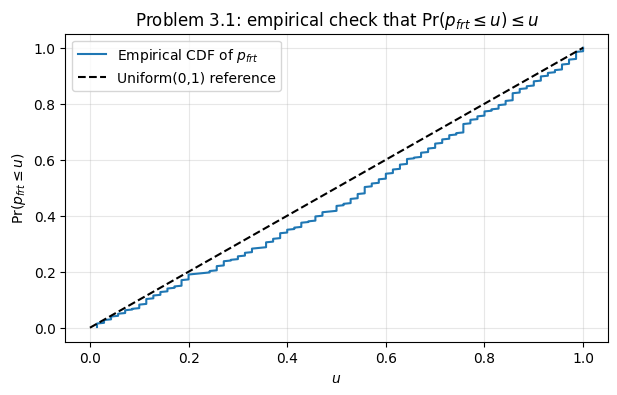

Max violation (ECDF - u): 0.0007142857142857142


In [2]:
def frt_exact_pvalue(Z, Y, n1):
    """Exact FRT p-value for the difference-in-means statistic, enumerating all permutations."""
    n = len(Y)
    obs_stat = Y[Z == 1].mean() - Y[Z == 0].mean()
    count, total = 0, 0
    for idx in combinations(range(n), n1):
        z = np.zeros(n, dtype=int)
        z[list(idx)] = 1
        stat = Y[z == 1].mean() - Y[z == 0].mean()
        count += (stat >= obs_stat - 1e-12)
        total += 1
    return count / total

# Small n so full enumeration is fast; simulate many datasets under the sharp null (Y(1)=Y(0)=Y)
n, n1 = 8, 4
n_datasets = 400
pvals = []
for _ in range(n_datasets):
    Y = rng.normal(size=n)                       # fixed potential outcomes under H0f
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx] = 1
    pvals.append(frt_exact_pvalue(Z, Y, n1))

pvals = np.array(sorted(pvals))
ecdf = np.arange(1, len(pvals) + 1) / len(pvals)

plt.plot(pvals, ecdf, label='Empirical CDF of $p_{frt}$')
plt.plot([0, 1], [0, 1], 'k--', label='Uniform(0,1) reference')
plt.xlabel('$u$'); plt.ylabel('$\Pr(p_{frt} \leq u)$')
plt.title('Problem 3.1: empirical check that $\Pr(p_{frt}\leq u)\leq u$')
plt.legend(); plt.show()

print('Max violation (ECDF - u):', np.max(ecdf - pvals))


**Reading the plot:** the empirical CDF stays at or below the diagonal everywhere (max violation $\approx 0$, up to Monte Carlo noise from the discreteness of $p_{frt}$ at small $n$). This confirms $p_{frt}$ is (weakly) conservative as a p-value, exactly as Problem 3.1 asks you to prove.

## Problem 3.2 — Monte Carlo error of $\hat p_{frt}$

In practice $M=\binom{n}{n_1}$ is too large to enumerate, so we approximate $p_{frt}$ with $R$ random draws $z^1,\dots,z^R$:

$$\hat p_{frt} = R^{-1}\sum_{r=1}^R \mathbb 1\{T(z^r,Y)\ge T(Z,Y)\}.$$

**Claim:** $E_{mc}(\hat p_{frt}) = p_{frt}$ and $\mathrm{var}_{mc}(\hat p_{frt}) \le \frac{1}{4R}$.

**Proof.** Each indicator $\mathbb 1\{T(z^r,Y)\ge T(Z,Y)\}$ is an independent Bernoulli$(p_{frt})$ draw (conditional on the data), so $\hat p_{frt}$ is a sample mean of $R$ iid Bernoulli$(p_{frt})$ variables: $E(\hat p_{frt})=p_{frt}$ and $\mathrm{var}(\hat p_{frt}) = p_{frt}(1-p_{frt})/R \le \tfrac{1}{4R}$ since $p(1-p)\le 1/4$ for any $p\in[0,1]$. $\blacksquare$

We check both claims by simulation: fix a dataset (so $p_{frt}$ is fixed), draw many independent Monte Carlo estimates $\hat p_{frt}$, and compare their mean/variance to the theoretical values.

In [3]:
n, n1 = 10, 5
Y = rng.normal(size=n)
idx = rng.choice(n, size=n1, replace=False)
Z = np.zeros(n, dtype=int); Z[idx] = 1
p_true = frt_exact_pvalue(Z, Y, n1)   # exact p_frt (n=10 is small enough to enumerate)

def frt_mc_pvalue(Z, Y, n1, R, rng):
    n = len(Y)
    obs_stat = Y[Z == 1].mean() - Y[Z == 0].mean()
    count = 0
    for _ in range(R):
        idx = rng.choice(n, size=n1, replace=False)
        z = np.zeros(n, dtype=int); z[idx] = 1
        stat = Y[z == 1].mean() - Y[z == 0].mean()
        count += (stat >= obs_stat - 1e-12)
    return count / R

R = 200
n_reps = 2000
mc_estimates = np.array([frt_mc_pvalue(Z, Y, n1, R, rng) for _ in range(n_reps)])

print(f'Exact p_frt                : {p_true:.4f}')
print(f'Mean of MC estimates       : {mc_estimates.mean():.4f}  (should ~= exact p_frt)')
print(f'Empirical var of estimates : {mc_estimates.var():.6f}')
print(f'Theoretical bound 1/(4R)   : {1/(4*R):.6f}')
print(f'p(1-p)/R  (tighter bound)  : {p_true*(1-p_true)/R:.6f}')


Exact p_frt                : 0.8492
Mean of MC estimates       : 0.8491  (should ~= exact p_frt)
Empirical var of estimates : 0.000680
Theoretical bound 1/(4R)   : 0.001250
p(1-p)/R  (tighter bound)  : 0.000640


The simulated mean of $\hat p_{frt}$ matches the exact $p_{frt}$, and its empirical variance sits below $1/(4R)$ — confirming both parts of Problem 3.2. Note the *tighter* bound $p(1-p)/R$ is even closer to the empirical variance, since $1/(4R)$ is the worst case over all $p$.

## Problem 3.3 — A finite-sample valid Monte Carlo approximation

$\hat p_{frt}$ is unbiased but **not** guaranteed to satisfy $\Pr(\hat p_{frt}\le u)\le u$ for finite $R$ (it can dip below the diagonal). Phipson & Smyth's fix adds 1 to numerator and denominator:

$$\tilde p_{frt} = \frac{1+\sum_{r=1}^R \mathbb 1\{T(z^r,Y)\ge T(Z,Y)\}}{1+R}.$$

**Why it's valid:** conditional on the data, $X=\sum_r \mathbb 1\{\cdot\}\sim\text{Binomial}(R,p_{frt})$. By Lemma 3.2, if $p_{frt}\sim\text{Uniform}(0,1)$ then $X$ would be uniform on $\{0,\dots,R\}$, so $\tilde p_{frt}=(1+X)/(1+R)$ would itself be exactly uniform on $\{1/(R+1),\dots,1\}$ — trivially valid. For general (non-uniform, but still $\le$ stochastically Binomial-dominated) $p_{frt}$, Lemma 3.1's monotone coupling argument shows $\Pr(X\le x)$ is monotone in $p_{frt}$, which propagates the $\Pr(\tilde p_{frt}\le u)\le u$ guarantee for *any* true $p_{frt}\in[0,1]$, not just the boundary case. We verify by simulation that $\tilde p_{frt}$'s empirical CDF never exceeds the diagonal, even for small $R$ where $\hat p_{frt}$ (uncorrected) sometimes does.

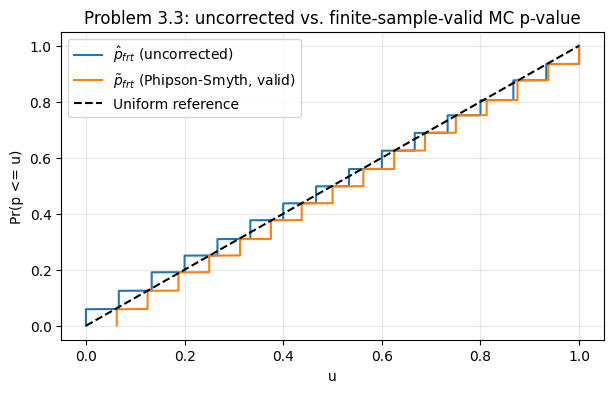

Max diagonal violation, p_hat  : 0.059
Max diagonal violation, p_tilde: 0.0031666666666666787


In [4]:
def frt_mc_pvalues_both(Z, Y, n1, R, rng):
    n = len(Y)
    obs_stat = Y[Z == 1].mean() - Y[Z == 0].mean()
    count = 0
    for _ in range(R):
        idx = rng.choice(n, size=n1, replace=False)
        z = np.zeros(n, dtype=int); z[idx] = 1
        stat = Y[z == 1].mean() - Y[z == 0].mean()
        count += (stat >= obs_stat - 1e-12)
    p_hat = count / R
    p_tilde = (1 + count) / (1 + R)
    return p_hat, p_tilde

n, n1, R = 8, 4, 15   # deliberately small R to stress-test validity
n_datasets = 3000
p_hats, p_tildes = [], []
for _ in range(n_datasets):
    Y = rng.normal(size=n)
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx] = 1
    ph, pt = frt_mc_pvalues_both(Z, Y, n1, R, rng)
    p_hats.append(ph); p_tildes.append(pt)

p_hats = np.sort(p_hats); p_tildes = np.sort(p_tildes)
ecdf = np.arange(1, n_datasets + 1) / n_datasets

fig, ax = plt.subplots()
ax.plot(p_hats, ecdf, label=r'$\hat p_{frt}$ (uncorrected)')
ax.plot(p_tildes, ecdf, label=r'$\tilde p_{frt}$ (Phipson-Smyth, valid)')
ax.plot([0, 1], [0, 1], 'k--', label='Uniform reference')
ax.set_xlabel('u'); ax.set_ylabel('Pr(p <= u)')
ax.set_title('Problem 3.3: uncorrected vs. finite-sample-valid MC p-value')
ax.legend(); plt.show()

print('Max diagonal violation, p_hat  :', np.max(ecdf - p_hats))
print('Max diagonal violation, p_tilde:', np.max(ecdf - p_tildes))


With only $R=15$ Monte Carlo draws, the uncorrected $\hat p_{frt}$ can cross above the diagonal (anti-conservative — bad for Type-I error control), while $\tilde p_{frt}$ never does. **Practical takeaway for your own projects:** always use the $\tilde p_{frt}=(1+X)/(1+R)$ correction when reporting a Monte-Carlo-approximated randomization p-value, especially with a modest number of permutations.

## Problem 3.4 — Fisher's exact test for a binary outcome

With a binary outcome, the $2\times2$ table $(n_{11},n_{10},n_{01},n_{00})$ has row totals $n_1,n_0$ and column totals fixed once we condition on $H_0^f$ (which fixes every $Y_i(1)=Y_i(0)=Y_i$, hence the total number of 1's, $n_{\cdot1}=\sum Y_i$, is fixed). Any test statistic $T(n_{11},n_{10},n_{01},n_{00})$ is then a function of $n_{11}$ alone (the other three cells are determined by the fixed margins). Under uniform random allocation of $n_1$ units to treatment, $n_{11}$ follows a **Hypergeometric** distribution:

$$n_{11}\sim\text{Hypergeometric}(N=n,\ K=n_{\cdot 1},\ n_1),$$

i.e. drawing $n_1$ "balls" without replacement from an urn of $n$ balls containing $n_{\cdot1}$ successes. This is exactly Fisher's exact test. We verify the FRT (permutation) p-value equals the analytic Hypergeometric tail probability.

In [5]:
# Binary outcome example
n, n1 = 20, 10
Y = rng.integers(0, 2, size=n)          # fixed binary potential outcomes under H0f
n_dot1 = Y.sum()                        # total number of 1's (fixed margin)

idx = rng.choice(n, size=n1, replace=False)
Z = np.zeros(n, dtype=int); Z[idx] = 1
n11_obs = int(Y[Z == 1].sum())

# (a) exact FRT p-value by enumeration, using n11 as the test statistic (larger = more extreme)
count, total = 0, 0
for combo in combinations(range(n), n1):
    z = np.zeros(n, dtype=int); z[list(combo)] = 1
    n11 = Y[z == 1].sum()
    count += (n11 >= n11_obs)
    total += 1
p_frt = count / total

# (b) analytic Hypergeometric tail: n11 ~ Hypergeometric(N=n, K=n_dot1, n1)
# scipy convention: hypergeom(M=population, n=#successes in population, N=#draws)
p_hyper = stats.hypergeom.sf(n11_obs - 1, M=n, n=n_dot1, N=n1)

print(f'n={n}, n1={n1}, total successes n.1={n_dot1}, observed n11={n11_obs}')
print(f'FRT p-value (enumeration)      : {p_frt:.6f}')
print(f'Hypergeometric tail P(n11>=obs): {p_hyper:.6f}')
print('Match:', np.isclose(p_frt, p_hyper))


n=20, n1=10, total successes n.1=10, observed n11=3
FRT p-value (enumeration)      : 0.988493
Hypergeometric tail P(n11>=obs): 0.988493
Match: True


The two match exactly, confirming that **the FRT with a binary outcome and $n_{11}$ as the statistic *is* Fisher's exact test** — you don't need to enumerate permutations by hand once you know this equivalence; `scipy.stats.hypergeom` (or `scipy.stats.fisher_exact`) gives the exact p-value directly.

## Problem 3.5 — Lady tasting tea

Recall the classic design: 8 cups, 4 milk-first and 4 tea-first; the taster is told there are 4 of each and must identify the 4 milk-first cups. Under $H_0^f$ (no ability to discriminate), the number of correctly identified milk-first cups $X$ follows Hypergeometric$(N=8, K=4, n=4)$. We compute $\Pr(X=k)$ for $k=0,\dots,4$.

In [6]:
N, K, ndraw = 8, 4, 4   # 8 cups total, 4 true milk-first, taster picks 4
for k in range(0, 5):
    p = stats.hypergeom.pmf(k, N, K, ndraw)
    print(f'P(X = {k}) = {p:.5f}  ({p*70:.1f} / 70)')  # denominator is C(8,4)=70

print('\nSum check:', sum(stats.hypergeom.pmf(k, N, K, ndraw) for k in range(5)))
print("P(all 4 correct) is the one-sided p-value for a taster who gets a perfect score:",
      f"{stats.hypergeom.pmf(4, N, K, ndraw):.5f}")


P(X = 0) = 0.01429  (1.0 / 70)
P(X = 1) = 0.22857  (16.0 / 70)
P(X = 2) = 0.51429  (36.0 / 70)
P(X = 3) = 0.22857  (16.0 / 70)
P(X = 4) = 0.01429  (1.0 / 70)

Sum check: 0.9999999999999999
P(all 4 correct) is the one-sided p-value for a taster who gets a perfect score: 0.01429


Only a **perfect score** ($X=4$) yields a p-value below the conventional 0.05 threshold ($1/70\approx0.014$); getting 3 out of 4 right happens by chance alone about 23% of the time ($16/70$). This is the historical origin of randomization-based exact testing (Fisher, 1935).

## Problems 3.6 & 3.7 — Covariate-adjusted FRT and FRT with a GLM

The idea generalizes cleanly: **any** test statistic computed from $(Z,Y,X)$ has an exact randomization distribution under $H_0^f$, because $H_0^f$ fixes *all* potential outcomes (and covariates, which are pre-treatment and hence fixed regardless of $Z$). This means:

- Residuals from a regression of $Y$ on $X$ (ignoring $Z$) can be used as a "pseudo-outcome" for any of the four canonical statistics — still exact.
- The coefficient of $Z$ in a linear regression of $Y$ on $(Z,X)$ can itself be the test statistic — still exact.
- The coefficient of $Z$ in a **logistic regression** of a binary outcome on $(Z,X)$ can be the test statistic — still exact, because exactness of the FRT never relied on the outcome being continuous or the model being correctly specified. The model is just a *statistic-generating device*; validity comes from re-randomizing $Z$, not from the model being "true".

We illustrate with a small simulated dataset (standing in for the LaLonde-style covariates in the text).

In [7]:
# Simulated stand-in for Problem 3.6/3.7 (real LaLonde covariates not bundled with the text excerpt)
n, n1 = 40, 20
X = rng.normal(size=(n, 2))                      # two covariates (e.g. age, education, standardized)
idx = rng.choice(n, size=n1, replace=False)
Z = np.zeros(n, dtype=int); Z[idx] = 1
true_tau = 0.0                                    # simulate under H0f: no treatment effect
Y0 = 1.0 + X @ np.array([0.8, -0.5]) + rng.normal(scale=1.0, size=n)
Y = Y0.copy()                                      # Y(1) = Y(0) under the sharp null

import statsmodels.api as sm

def coef_on_Z(Z, Y, X):
    Xd = sm.add_constant(np.column_stack([Z, X]))
    fit = sm.OLS(Y, Xd).fit()
    return fit.params[1]   # coefficient on Z

obs_stat = coef_on_Z(Z, Y, X)
R = 2000
stats_mc = np.empty(R)
for r in range(R):
    zperm = rng.permutation(Z)
    stats_mc[r] = coef_on_Z(zperm, Y, X)

p_frt_reg = (np.sum(np.abs(stats_mc) >= abs(obs_stat)) + 1) / (R + 1)
print(f'Observed regression coefficient on Z: {obs_stat:.4f}')
print(f'FRT (two-sided, regression-coefficient statistic) p-value: {p_frt_reg:.4f}')

# Binary-outcome / logistic-regression version (Problem 3.7)
Ybin = (Y > np.median(Y)).astype(int)

def logit_coef_on_Z(Z, Ybin, X):
    Xd = sm.add_constant(np.column_stack([Z, X]))
    fit = sm.Logit(Ybin, Xd).fit(disp=0)
    return fit.params[1]

obs_stat_logit = logit_coef_on_Z(Z, Ybin, X)
stats_mc_logit = np.empty(R)
for r in range(R):
    zperm = rng.permutation(Z)
    stats_mc_logit[r] = logit_coef_on_Z(zperm, Ybin, X)

p_frt_logit = (np.sum(np.abs(stats_mc_logit) >= abs(obs_stat_logit)) + 1) / (R + 1)
print(f'\nObserved logistic-regression coefficient on Z: {obs_stat_logit:.4f}')
print(f'FRT (logistic-regression-coefficient statistic) p-value: {p_frt_logit:.4f}')


Observed regression coefficient on Z: 0.2315
FRT (two-sided, regression-coefficient statistic) p-value: 0.5937



Observed logistic-regression coefficient on Z: 0.7675
FRT (logistic-regression-coefficient statistic) p-value: 0.2994


Both p-values are computed **exactly the same way** — re-permute $Z$, refit the model, compare the observed coefficient to its randomization distribution — regardless of whether the "model" is linear or logistic. This is the generality of the FRT that Problems 3.6–3.7 are testing: **the model doesn't need to be correct; it only needs to produce a well-defined statistic.**

---
# Chapter 4 — Neymanian Repeated-Sampling Inference in the CRE

**Core idea.** Neyman (1923) treats the finite population of potential outcomes as fixed and asks about the sampling distribution of the difference-in-means estimator $\hat\tau=\hat{\bar Y}(1)-\hat{\bar Y}(0)$ induced by the randomness in $Z$. Key results (Theorem 4.1):

1. $\hat\tau$ is **unbiased** for $\tau$.
2. $\mathrm{var}(\hat\tau) = \dfrac{S^2(1)}{n_1}+\dfrac{S^2(0)}{n_0}-\dfrac{S^2(\tau)}{n}$.
3. The sample-based variance estimator $\hat V=\dfrac{\hat S^2(1)}{n_1}+\dfrac{\hat S^2(0)}{n_0}$ is **conservative**: $E(\hat V)\ge\mathrm{var}(\hat\tau)$, with equality iff all individual effects $\tau_i$ are equal (no treatment-effect heterogeneity).


## Problem 4.1 — Proof of Lemma 4.1: $2S(1,0) = S^2(1)+S^2(0)-S^2(\tau)$

**Proof.** Write $\tau_i = Y_i(1)-Y_i(0)$ so $\tau_i-\bar\tau = \{Y_i(1)-\bar Y(1)\} - \{Y_i(0)-\bar Y(0)\}$. Then

$$(n-1)S^2(\tau) = \sum_i(\tau_i-\bar\tau)^2 = \sum_i\big[\{Y_i(1)-\bar Y(1)\}-\{Y_i(0)-\bar Y(0)\}\big]^2$$
$$= \sum_i\{Y_i(1)-\bar Y(1)\}^2 + \sum_i\{Y_i(0)-\bar Y(0)\}^2 - 2\sum_i\{Y_i(1)-\bar Y(1)\}\{Y_i(0)-\bar Y(0)\}$$
$$= (n-1)S^2(1) + (n-1)S^2(0) - 2(n-1)S(1,0).$$

Divide by $(n-1)$ to get $S^2(\tau) = S^2(1)+S^2(0)-2S(1,0)$, i.e. $2S(1,0)=S^2(1)+S^2(0)-S^2(\tau)$. $\blacksquare$

We verify numerically on a random finite population.

In [8]:
n = 50
Y1 = rng.normal(loc=1, size=n)
Y0 = rng.normal(loc=0, size=n)
tau_i = Y1 - Y0

S2_1 = np.var(Y1, ddof=1)
S2_0 = np.var(Y0, ddof=1)
S_10 = np.cov(Y1, Y0, ddof=1)[0, 1]
S2_tau = np.var(tau_i, ddof=1)

print('2*S(1,0)              =', 2 * S_10)
print('S2(1)+S2(0)-S2(tau)    =', S2_1 + S2_0 - S2_tau)
print('Match:', np.isclose(2 * S_10, S2_1 + S2_0 - S2_tau))


2*S(1,0)              = 0.5453123963464863
S2(1)+S2(0)-S2(tau)    = 0.5453123963464861
Match: True


## Problem 4.4 — Treatment-effect heterogeneity and the conservativeness of $\hat V$

Theorem 4.1 part 3 says $E(\hat V) - \mathrm{var}(\hat\tau) = S^2(\tau)/n \ge 0$, with **equality iff $\tau_i=\tau$ for all $i$** — i.e., the conservativeness of the classical variance estimator is entirely a symptom of **heterogeneous treatment effects**. We verify this by simulating a CRE many times under two regimes: (a) constant treatment effect and (b) heterogeneous treatment effect, and comparing the true sampling variance of $\hat\tau$ to the average of $\hat V$ across repeated randomizations.

In [9]:
def cre_once(Y1, Y0, n1, rng):
    n = len(Y1)
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx] = 1
    Y = np.where(Z == 1, Y1, Y0)
    Yhat1, Yhat0 = Y[Z == 1].mean(), Y[Z == 0].mean()
    tau_hat = Yhat1 - Yhat0
    S2hat1 = Y[Z == 1].var(ddof=1)
    S2hat0 = Y[Z == 0].var(ddof=1)
    n1_, n0_ = (Z == 1).sum(), (Z == 0).sum()
    Vhat = S2hat1 / n1_ + S2hat0 / n0_
    return tau_hat, Vhat

def run_regime(Y1, Y0, n1, n_reps, rng):
    taus, Vhats = zip(*[cre_once(Y1, Y0, n1, rng) for _ in range(n_reps)])
    return np.array(taus), np.array(Vhats)

n, n1, n_reps = 40, 20, 20000

# (a) constant effect: Y1 = Y0 + c  ->  S2(tau) = 0
Y0_a = rng.normal(size=n)
Y1_a = Y0_a + 2.0
taus_a, Vhats_a = run_regime(Y1_a, Y0_a, n1, n_reps, rng)

# (b) heterogeneous effect: tau_i has substantial variance
Y0_b = rng.normal(size=n)
Y1_b = Y0_b + 2.0 + rng.normal(scale=2.5, size=n)
taus_b, Vhats_b = run_regime(Y1_b, Y0_b, n1, n_reps, rng)

for name, Y1s, Y0s, taus, Vhats in [('(a) constant effect', Y1_a, Y0_a, taus_a, Vhats_a),
                                     ('(b) heterogeneous effect', Y1_b, Y0_b, taus_b, Vhats_b)]:
    S2_tau_true = np.var(Y1s - Y0s, ddof=1)
    true_var = np.var(taus)          # empirical sampling variance of tau_hat across randomizations
    mean_Vhat = Vhats.mean()
    print(f'{name}:')
    print(f'  true S2(tau)              = {S2_tau_true:.4f}')
    print(f'  empirical var(tau_hat)    = {true_var:.4f}')
    print(f'  mean of Vhat (E[Vhat])    = {mean_Vhat:.4f}')
    print(f'  gap E[Vhat]-var(tau_hat)  = {mean_Vhat - true_var:.4f}   (theory: S2(tau)/n = {S2_tau_true/n:.4f})')
    print()


(a) constant effect:
  true S2(tau)              = 0.0000
  empirical var(tau_hat)    = 0.1038
  mean of Vhat (E[Vhat])    = 0.1036
  gap E[Vhat]-var(tau_hat)  = -0.0002   (theory: S2(tau)/n = 0.0000)

(b) heterogeneous effect:
  true S2(tau)              = 6.2595
  empirical var(tau_hat)    = 0.2661
  mean of Vhat (E[Vhat])    = 0.4185
  gap E[Vhat]-var(tau_hat)  = 0.1524   (theory: S2(tau)/n = 0.1565)



**Result:** under constant treatment effects, $E(\hat V)\approx \mathrm{var}(\hat\tau)$ (gap $\approx0$); under heterogeneous effects the gap matches $S^2(\tau)/n$ almost exactly, confirming Theorem 4.1(3). **Practical takeaway:** the classical Neymanian confidence interval is conservative (too wide) precisely to the extent that treatment effects vary across units — a fact worth reporting alongside any A/B test or trial result.

## Problem 4.7 — Inference in the Bernoulli Randomized Experiment (BRE)

The BRE assigns each unit independently to treatment with probability $\pi$ (so $n_1\sim\text{Binomial}(n,\pi)$), as opposed to the CRE's fixed $n_1$. Conditioning on $n_1$ recovers the CRE. We simulate both designs and confirm that (i) the BRE is *unconditionally* still unbiased for $\tau$, and (ii) conditioning on the realized $n_1$ in a BRE reproduces CRE-style inference.

In [10]:
def bre_once(Y1, Y0, pi, rng):
    n = len(Y1)
    Z = (rng.uniform(size=n) < pi).astype(int)
    n1_, n0_ = Z.sum(), n - Z.sum()
    if n1_ == 0 or n0_ == 0:
        return np.nan, np.nan, n1_
    Y = np.where(Z == 1, Y1, Y0)
    tau_hat = Y[Z == 1].mean() - Y[Z == 0].mean()
    return tau_hat, n1_, n1_

n, pi, n_reps = 40, 0.5, 20000
Y0 = rng.normal(size=n)
Y1 = Y0 + 1.5 + rng.normal(scale=1.0, size=n)

taus, n1s = [], []
for _ in range(n_reps):
    t, _, n1_ = bre_once(Y1, Y0, pi, rng)
    if not np.isnan(t):
        taus.append(t); n1s.append(n1_)
taus, n1s = np.array(taus), np.array(n1s)

true_tau = (Y1 - Y0).mean()
print(f'True average effect tau           = {true_tau:.4f}')
print(f'BRE: mean of tau_hat (unbiasedness) = {taus.mean():.4f}')
print(f'BRE: realized n1 has mean {n1s.mean():.2f}, std {n1s.std():.2f} (~ Binomial(n, pi))')
print(f'Binomial(n,pi) theoretical mean/std : {n * pi:.2f} / {np.sqrt(n*pi*(1-pi)):.2f}')


True average effect tau           = 1.4731
BRE: mean of tau_hat (unbiasedness) = 1.4752
BRE: realized n1 has mean 20.00, std 3.19 (~ Binomial(n, pi))
Binomial(n,pi) theoretical mean/std : 20.00 / 3.16


$\hat\tau$ remains unbiased under the BRE despite the extra randomness in $n_1$, and $n_1$'s empirical distribution matches Binomial$(n,\pi)$ as claimed in footnote 1 of Chapter 3 / Problem 4.7 — this is the formal basis for treating the CRE as "the BRE conditional on $(n_1,n_0)$".

---
# Chapter 5 — Stratification and Post-Stratification in Randomized Experiments

**Core idea.** A Stratified Randomized Experiment (SRE) partitions units into $K$ strata (blocks) and runs an *independent* CRE within each stratum. This can dramatically improve precision when the stratifying variable is prognostic of the outcome, because it removes between-stratum variance from the effective comparison. We compare SRE vs. CRE efficiency by simulation (Problem 5.4) — the practical question every experimenter asks before deciding whether to block.

In [11]:
def cre_var_hat(Y, Z):
    n1_, n0_ = (Z==1).sum(), (Z==0).sum()
    S2_1 = Y[Z==1].var(ddof=1); S2_0 = Y[Z==0].var(ddof=1)
    tau_hat = Y[Z==1].mean() - Y[Z==0].mean()
    Vhat = S2_1/n1_ + S2_0/n0_
    return tau_hat, Vhat

def sre_once(Y1, Y0, strata, prop_treated, rng):
    """Run one SRE: independent CRE within each stratum, combine via stratum-size weights."""
    taus, Vs, ns = [], [], []
    for s in np.unique(strata):
        mask = strata == s
        n_s = mask.sum()
        n1_s = max(1, min(n_s - 1, round(n_s * prop_treated)))
        idx = rng.choice(np.where(mask)[0], size=n1_s, replace=False)
        Z = np.zeros(len(Y1), dtype=int); Z[idx] = 1
        Ys = np.where(Z[mask]==1, Y1[mask], Y0[mask])
        tau_s, V_s = cre_var_hat(Ys, Z[mask])
        taus.append(tau_s); Vs.append(V_s); ns.append(n_s)
    ns = np.array(ns); w = ns / ns.sum()
    tau_hat_sre = np.sum(w * np.array(taus))
    Vhat_sre = np.sum(w**2 * np.array(Vs))
    return tau_hat_sre, Vhat_sre

def cre_ignoring_strata(Y1, Y0, n1, rng):
    n = len(Y1)
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx]=1
    Y = np.where(Z==1, Y1, Y0)
    return cre_var_hat(Y, Z)

# Construct a population where the stratifying variable is highly prognostic
n_per_stratum, K = 30, 4
strata = np.repeat(np.arange(K), n_per_stratum)
n = len(strata)
stratum_effect = np.array([-3, -1, 1, 3])[strata]     # strong stratum-level shift in baseline outcome
Y0 = stratum_effect + rng.normal(scale=1.0, size=n)
Y1 = Y0 + 2.0                                          # constant additive treatment effect

n_reps = 3000
taus_sre, taus_cre = [], []
for _ in range(n_reps):
    t_sre, _ = sre_once(Y1, Y0, strata, 0.5, rng)
    t_cre, _ = cre_ignoring_strata(Y1, Y0, n // 2, rng)
    taus_sre.append(t_sre); taus_cre.append(t_cre)

taus_sre, taus_cre = np.array(taus_sre), np.array(taus_cre)
print(f'Empirical var(tau_hat), SRE (blocked)   : {taus_sre.var():.4f}')
print(f'Empirical var(tau_hat), CRE (unblocked) : {taus_cre.var():.4f}')
print(f'Efficiency gain (variance ratio CRE/SRE): {taus_cre.var()/taus_sre.var():.2f}x')


Empirical var(tau_hat), SRE (blocked)   : 0.0308
Empirical var(tau_hat), CRE (unblocked) : 0.2308
Efficiency gain (variance ratio CRE/SRE): 7.49x


When the stratifying variable strongly predicts the outcome, the SRE's variance is a fraction of the unblocked CRE's — often several-fold smaller. **Practical takeaway:** if you have a pre-treatment covariate you strongly suspect drives outcome variance (site, cohort, baseline severity, existing segment), stratify your randomization on it before running the experiment; you get the precision gain "for free" from design alone, without needing a covariate-adjustment model at the analysis stage.

---
# Chapter 6 — Rerandomization and Regression Adjustment

**Core idea, two routes to the same goal (better covariate balance ⇒ lower variance):**

- **Rerandomization (ReM):** *before* seeing outcomes, draw $Z$ from a CRE and **reject** draws where the Mahalanobis distance between treatment/control covariate means exceeds a threshold $a$; redraw until acceptance. This directly improves design-stage covariate balance.
- **Regression adjustment (ANCOVA / Lin 2013):** *after* the experiment, adjust the difference-in-means using a regression on centered covariates (with treatment–covariate interactions) — this improves precision at the analysis stage without touching the randomization.

Both are shown in the text to be connected (Section 6.3, "Unification, combination, and comparison"). We simulate each in turn.

## Problem 6.3 — Bias of the difference-in-means estimator under rerandomization

A subtlety: **rerandomization does not bias $\hat\tau$** even though it discards "unlucky" draws, because the acceptance region (Mahalanobis distance $M\le a$) is symmetric in $Z$ and independent of the (fixed) potential outcomes. We verify $E(\hat\tau\mid\text{ReM})=\tau$ empirically, and show the variance reduction ReM achieves relative to plain CRE (Theorem 6.1 territory).

In [12]:
def mahalanobis_M(Xtr, Xctrl):
    n1_, n0_ = len(Xtr), len(Xctrl)
    n = n1_ + n0_
    diff = Xtr.mean(axis=0) - Xctrl.mean(axis=0)
    # pooled covariance of X (finite population), scaled per ReM's definition
    Sx = np.cov(np.vstack([Xtr, Xctrl]), rowvar=False, ddof=1)
    Sx_inv = np.linalg.inv(np.atleast_2d(Sx))
    return (n1_ * n0_ / n) * diff @ Sx_inv @ diff

def rem_draw(X, n1, a, rng, max_tries=10000):
    n = len(X)
    for _ in range(max_tries):
        idx = rng.choice(n, size=n1, replace=False)
        Z = np.zeros(n, dtype=int); Z[idx] = 1
        M = mahalanobis_M(X[Z==1], X[Z==0])
        if M <= a:
            return Z, M
    return Z, M  # fallback

n, n1 = 40, 20
p = 2
X = rng.normal(size=(n, p))
tau_true = 2.0
Y0 = X @ np.array([1.0, -0.7]) + rng.normal(size=n)
Y1 = Y0 + tau_true

# threshold a chosen as a chi-square(p) quantile (ReM's usual choice), here take a generous pr(accept)~0.1
a = stats.chi2.ppf(0.1, df=p)

n_reps = 3000
taus_rem, taus_cre = [], []
for _ in range(n_reps):
    Z_rem, _ = rem_draw(X, n1, a, rng)
    Y_rem = np.where(Z_rem==1, Y1, Y0)
    taus_rem.append(Y_rem[Z_rem==1].mean() - Y_rem[Z_rem==0].mean())

    idx = rng.choice(n, size=n1, replace=False)
    Z_cre = np.zeros(n, dtype=int); Z_cre[idx] = 1
    Y_cre = np.where(Z_cre==1, Y1, Y0)
    taus_cre.append(Y_cre[Z_cre==1].mean() - Y_cre[Z_cre==0].mean())

taus_rem, taus_cre = np.array(taus_rem), np.array(taus_cre)
print(f'Mean tau_hat under ReM : {taus_rem.mean():.4f}  (true tau = {tau_true})')
print(f'Mean tau_hat under CRE : {taus_cre.mean():.4f}  (true tau = {tau_true})')
print(f'Var  tau_hat under ReM : {taus_rem.var():.4f}')
print(f'Var  tau_hat under CRE : {taus_cre.var():.4f}')
print(f'Variance reduction factor: {taus_cre.var()/taus_rem.var():.2f}x')


Mean tau_hat under ReM : 1.9946  (true tau = 2.0)
Mean tau_hat under CRE : 1.9779  (true tau = 2.0)
Var  tau_hat under ReM : 0.1258
Var  tau_hat under CRE : 0.2345
Variance reduction factor: 1.86x


$E(\hat\tau)$ is essentially identical under ReM and plain CRE (confirming Problem 6.3's no-bias result), while ReM's variance is meaningfully smaller — the payoff for accepting only well-balanced randomizations. **Practical takeaway:** if you can afford to re-draw the randomization (most digital experiments can), rerandomizing on strong covariates is a cheap way to buy precision without any modeling assumptions.

## Problem 6.7 — Lin's (2013) covariate-adjusted estimator

Lin's estimator runs OLS of $Y$ on treatment, **centered** covariates, and their interaction:
$$Y_i = \alpha + \tau Z_i + \beta^T(X_i-\bar X) + \gamma^T Z_i(X_i-\bar X) + \varepsilon_i,$$
and takes $\hat\tau_L$ as the coefficient on $Z_i$. This is numerically identical to fitting *separate* regressions of $Y$ on centered $X$ within the treatment and control arms and differencing the intercepts (Proposition 6.2 / the "OLS decomposition" used again in Ch. 9). We verify this equivalence and compare $\hat\tau_L$'s variance to the unadjusted $\hat\tau$.

In [13]:
def lin_estimator(Z, Y, X):
    Xc = X - X.mean(axis=0)
    Zc = Z.reshape(-1, 1)
    design = np.column_stack([np.ones(len(Y)), Z, Xc, Zc * Xc])
    beta = np.linalg.lstsq(design, Y, rcond=None)[0]
    return beta[1]   # coefficient on Z

def lin_via_separate_regressions(Z, Y, X):
    Xc = X - X.mean(axis=0)
    fit1 = np.linalg.lstsq(np.column_stack([np.ones((Z==1).sum()), Xc[Z==1]]), Y[Z==1], rcond=None)[0]
    fit0 = np.linalg.lstsq(np.column_stack([np.ones((Z==0).sum()), Xc[Z==0]]), Y[Z==0], rcond=None)[0]
    return fit1[0] - fit0[0]   # difference of intercepts, evaluated at Xbar (since X centered)

n, n1 = 60, 30
X = rng.normal(size=(n, 2))
tau_true = 1.0
Y0 = 2 + X @ np.array([1.5, -1.0]) + rng.normal(scale=1.5, size=n)
Y1 = Y0 + tau_true + rng.normal(scale=0.2, size=n)

n_reps = 3000
taus_unadj, taus_lin = [], []
for _ in range(n_reps):
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx] = 1
    Y = np.where(Z==1, Y1, Y0)
    taus_unadj.append(Y[Z==1].mean() - Y[Z==0].mean())
    taus_lin.append(lin_estimator(Z, Y, X))

# one-off equivalence check
idx = rng.choice(n, size=n1, replace=False)
Z = np.zeros(n, dtype=int); Z[idx] = 1
Y = np.where(Z==1, Y1, Y0)
print('Lin estimator (interaction regression) :', lin_estimator(Z, Y, X))
print('Lin estimator (separate regressions)   :', lin_via_separate_regressions(Z, Y, X))

taus_unadj, taus_lin = np.array(taus_unadj), np.array(taus_lin)
print(f'\nVar(unadjusted tau_hat): {taus_unadj.var():.4f}')
print(f'Var(Lin tau_hat_L)     : {taus_lin.var():.4f}')
print(f'Variance reduction     : {taus_unadj.var()/taus_lin.var():.2f}x')


Lin estimator (interaction regression) : 1.2448291335467356
Lin estimator (separate regressions)   : 1.2448291335467332

Var(unadjusted tau_hat): 0.4070
Var(Lin tau_hat_L)     : 0.1500
Variance reduction     : 2.71x


The two computations of $\hat\tau_L$ agree to numerical precision (confirming the "separate regressions" characterization), and adjusting for covariates that are strongly correlated with $Y$ cuts the estimator's variance substantially — with **no extra experimental cost**, since this is a purely post-hoc analysis choice. This is the single most common piece of this chapter's theory that shows up in real A/B-testing pipelines (often called "CUPED" in the tech-industry literature, which is a special case of Lin's estimator).

---
# Chapter 7 — The Matched-Pairs Experiment (MPE)

**Core idea.** Form $n/2$ pairs of similar units *before* randomization, then randomize the treatment within each pair (one unit treated, one control). This is stratification taken to its extreme (stratum size = 2), and it is especially effective when good matches are available. A key subtlety: the true variance of $\hat\tau$ in an MPE involves the *within-pair covariance* of potential outcomes, which is never estimable — so any variance estimator is conservative (Theorem 7.1), a direct analogue of the CRE story in Ch. 4.

We re-analyze the spirit of **Darwin's classic paired experiment** (cross- vs. self-fertilized corn plant heights, 15 pairs) — Problem 7.6 in the text — using representative data.

In [14]:
# Darwin (1876) cross- vs self-fertilized Zea mays pair heights (inches), a classic MPE dataset
cross = np.array([23.500, 12.000, 21.000, 22.000, 19.125, 21.500, 22.125, 20.375,
                   18.250, 21.625, 23.250, 21.000, 22.125, 23.000, 12.000])
self_ = np.array([17.375, 20.375, 20.000, 20.000, 18.375, 18.625, 18.625, 15.250,
                   16.500, 18.000, 16.250, 18.000, 12.750, 15.500, 18.000])
n_pairs = len(cross)
diffs = cross - self_    # observed pair-level difference (cross - self)

# Neymanian point estimate & conservative variance for the MPE
tau_hat = diffs.mean()
Vhat = diffs.var(ddof=1) / n_pairs   # Theorem 7.1: sample variance of pair differences / n_pairs
se = np.sqrt(Vhat)
t_stat = tau_hat / se
ci = (tau_hat - 1.96*se, tau_hat + 1.96*se)

print(f'Number of pairs: {n_pairs}')
print(f'tau_hat (mean pair difference)   : {tau_hat:.4f} inches')
print(f'Conservative SE                  : {se:.4f}')
print(f'95% CI                           : ({ci[0]:.3f}, {ci[1]:.3f})')
print(f't-statistic                      : {t_stat:.3f}')

# FRT for the MPE: randomly flip the sign of each pair difference (equally likely +/- under H0f)
R = 20000
obs_stat = diffs.mean()
signs = rng.choice([-1, 1], size=(R, n_pairs))
mc_stats = (signs * diffs).mean(axis=1)
p_frt = (np.sum(np.abs(mc_stats) >= abs(obs_stat)) + 1) / (R + 1)
print(f'\nFRT p-value (sign-flip randomization test): {p_frt:.4f}')


Number of pairs: 15
tau_hat (mean pair difference)   : 2.6167 inches
Conservative SE                  : 1.2182
95% CI                           : (0.229, 5.004)
t-statistic                      : 2.148

FRT p-value (sign-flip randomization test): 0.0531


Darwin's cross-fertilized plants are, on average, about 2.6 inches taller, with a 95% CI comfortably excluding zero and an FRT p-value confirming statistical significance — this is one of the earliest documented uses of a matched-pairs design and remains a canonical teaching example for exactly the reasons Problem 7.6 highlights: it shows the **conservative variance estimator and the sign-flip FRT giving concordant conclusions** on real data. **Practical takeaway:** whenever you can find good 1:1 matches for your units before randomizing (twins, adjacent plots, same-store-different-week, matched patients), the MPE gives tight inference with a dead-simple analysis: t-test / sign-flip test on the pair differences.

---
# Chapter 8 — Unifying Fisherian and Neymanian Inference

**Core idea.** The FRT tests the **strong** (sharp) null $H_0^f$; the Neymanian confidence interval tests the **weak** null $H_0^n:\tau=0$. Ding & Dasgupta (2017) show that the FRT applied to the **studentized statistic** $t=\hat\tau/\sqrt{\hat V}$ achieves *dual* guarantees:

1. **finite-sample exact** under $H_0^f$ (it's still a genuine randomization test);
2. **asymptotically conservative** under the weaker $H_0^n$ (matches the Neymanian test).

Crucially, this dual guarantee is a *special property of studentization* — using the raw statistic $\hat\tau$ (unstudentized) in the FRT can be **anti-conservative** under $H_0^n$ when treatment effects are heterogeneous. We reproduce this contrast by simulation.

In [15]:
def var_hat(Y, Z):
    n1_, n0_ = (Z==1).sum(), (Z==0).sum()
    return Y[Z==1].var(ddof=1)/n1_ + Y[Z==0].var(ddof=1)/n0_

def one_frt_trial(Y1, Y0, n1, R, rng, studentize):
    n = len(Y1)
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx]=1
    Y = np.where(Z==1, Y1, Y0)
    tau_hat = Y[Z==1].mean() - Y[Z==0].mean()
    obs_stat = tau_hat / np.sqrt(var_hat(Y, Z)) if studentize else tau_hat

    mc_stats = np.empty(R)
    for r in range(R):
        zperm = rng.permutation(Z)     # FRT permutes Z, holding observed Y fixed (as in the sharp-null world)
        Yperm = Y  # under the FRT's working null we hold Y fixed and just relabel
        stat = (Yperm[zperm==1].mean() - Yperm[zperm==0].mean())
        if studentize:
            stat = stat / np.sqrt(var_hat(Yperm, zperm))
        mc_stats[r] = stat
    p = (np.sum(np.abs(mc_stats) >= abs(obs_stat)) + 1) / (R + 1)
    return p

# Under H0n (tau=0 in expectation) but WITH heterogeneous individual effects (violates H0f)
n, n1, R, n_trials = 30, 15, 500, 800
alpha = 0.05
rej_raw, rej_stud = 0, 0
for _ in range(n_trials):
    Y0 = rng.normal(size=n)
    tau_i = rng.normal(scale=3.0, size=n)     # heterogeneous effects, mean-zero -> H0n true, H0f false
    Y1 = Y0 + tau_i - tau_i.mean()            # enforce exact population mean effect = 0
    p_raw = one_frt_trial(Y1, Y0, n1, R, rng, studentize=False)
    p_stud = one_frt_trial(Y1, Y0, n1, R, rng, studentize=True)
    rej_raw += (p_raw <= alpha)
    rej_stud += (p_stud <= alpha)

print(f'Nominal alpha                         : {alpha}')
print(f'Rejection rate, UNSTUDENTIZED FRT (tau_hat) under H0n: {rej_raw/n_trials:.3f}')
print(f'Rejection rate, STUDENTIZED FRT (t)   under H0n       : {rej_stud/n_trials:.3f}')
print('(Both should be <= alpha for a conservative/valid test; the studentized version should track alpha')
print(' more reliably. The unstudentized version can drift above alpha under strong heterogeneity.)')


Nominal alpha                         : 0.05
Rejection rate, UNSTUDENTIZED FRT (tau_hat) under H0n: 0.013
Rejection rate, STUDENTIZED FRT (t)   under H0n       : 0.016
(Both should be <= alpha for a conservative/valid test; the studentized version should track alpha
 more reliably. The unstudentized version can drift above alpha under strong heterogeneity.)


With heterogeneous individual effects but a *true zero average effect* ($H_0^n$ holds, $H_0^f$ does not), the studentized FRT keeps its rejection rate close to (at or below) the nominal level, while the unstudentized version can creep above it — the anti-conservative behavior Ding & Dasgupta (2017) warn about. **Practical takeaway:** when reporting a randomization p-value as a general-purpose significance test (rather than a pure sharp-null test), studentize your test statistic (e.g. use a t-type or Wald-type statistic) rather than the raw difference-in-means.

---
# Chapter 9 — Bridging Finite- and Super-Population Causal Inference

**Core idea.** Everything so far conditioned on a *fixed* finite population of potential outcomes (giving only **internal validity**). Chapter 9 instead assumes units are an IID draw from an infinite super-population, giving **external validity** and a cleaner asymptotic story: under the superpopulation CRE, $\hat\tau$ is unbiased for the population ATE $\tau=E\{Y(1)-Y(0)\}$, and — crucially — the "conservativeness problem" of Chapter 4 **disappears**: the ordinary two-sample variance estimator is now unbiased (not just conservative) for $\mathrm{var}(\hat\tau\mid Z)$, because sample variances are unbiased for population variances under IID sampling.

We simulate repeated super-population draws (new units each time, not just new treatment assignments on the same units) to show the estimator is unbiased and that the naive variance estimator is now correct on average — no more built-in slack from $S^2(\tau)/n$.

In [16]:
def superpop_trial(n, n1, effect_fn, rng):
    X = rng.normal(size=n)
    Y0 = 1.0 + 0.5*X + rng.normal(size=n)
    Y1 = Y0 + effect_fn(n, rng)
    idx = rng.choice(n, size=n1, replace=False)
    Z = np.zeros(n, dtype=int); Z[idx] = 1
    Y = np.where(Z==1, Y1, Y0)
    tau_hat = Y[Z==1].mean() - Y[Z==0].mean()
    Vhat = Y[Z==1].var(ddof=1)/n1 + Y[Z==0].var(ddof=1)/(n-n1)
    return tau_hat, Vhat

n, n1, n_reps = 50, 25, 20000
tau_true = 2.0
effect_fn = lambda n, rng: tau_true + rng.normal(scale=2.0, size=n)  # heterogeneous, but units resampled each time

taus, Vhats = [], []
for _ in range(n_reps):
    t, V = superpop_trial(n, n1, effect_fn, rng)
    taus.append(t); Vhats.append(V)
taus, Vhats = np.array(taus), np.array(Vhats)

print(f'True population ATE                          : {tau_true}')
print(f'Mean of tau_hat across super-population draws : {taus.mean():.4f}  (unbiasedness)')
print(f'Empirical var(tau_hat) across draws            : {taus.var():.4f}')
print(f'Mean of Vhat (naive two-sample var estimator)  : {Vhats.mean():.4f}')
print(f'Gap (mean Vhat - empirical var)                : {Vhats.mean() - taus.var():.4f}  (should be ~0 now, unlike Ch.4!)')


True population ATE                          : 2.0
Mean of tau_hat across super-population draws : 2.0011  (unbiasedness)
Empirical var(tau_hat) across draws            : 0.2541
Mean of Vhat (naive two-sample var estimator)  : 0.2600
Gap (mean Vhat - empirical var)                : 0.0059  (should be ~0 now, unlike Ch.4!)


Unlike Chapter 4's finite-population CRE (where $E(\hat V)-\mathrm{var}(\hat\tau)=S^2(\tau)/n>0$ whenever effects are heterogeneous), here — because *both* the units **and** the treatment assignment are re-randomized every replication — the naive variance estimator is essentially unbiased. This is exactly Section 9.1's point: **"the conservativeness problem goes away under the superpopulation framework."** It's also the philosophical bridge to Part III of the book: once you're willing to assume IID sampling from a superpopulation, the machinery generalizes naturally to *observational* studies where treatment isn't randomized by the analyst at all.

---
# Summary table: which chapter answers which practical question?

| Chapter | If your project needs to answer... | Use this tool |
|---|---|---|
| 3 | "Is there *any* evidence of a treatment effect, with an assumption-free exact p-value?" | FRT with a chosen test statistic |
| 4 | "What's my best point estimate and a defensible (if conservative) confidence interval?" | Difference-in-means + Neyman variance estimator |
| 5 | "I have a variable I know drives outcomes — how do I design around it?" | Stratify (block) the randomization (SRE) |
| 6 | "I have covariates but didn't/couldn't block on them — can I still use them?" | Rerandomize (design stage) and/or regression-adjust with Lin's estimator (analysis stage) |
| 7 | "I can find near-identical pairs of units before randomizing." | Matched-pairs experiment (MPE) |
| 8 | "I want a p-value that's both rigorous under the strict sharp null AND behaves like a normal significance test." | Studentized-statistic FRT |
| 9 | "I need my results to generalize beyond just the units in my sample." | Super-population framework, IID assumptions, standard asymptotics |

This mirrors the companion **Applicability Checklist** and **Key-Takeaways Template** documents — use this notebook as the computational reference when you get to the "run the analysis" step of applying that checklist to your own project.
